<a href="https://colab.research.google.com/github/ahmedsalha130/DataCleaning-Python-Main/blob/hawat/Data_Cleaing_GAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
import re
from collections import Counter

# =========================
# SETTINGS
# =========================

KOBO_TOKEN = "e99118b88e6edfdb76fa4fec51c1345e5e9b714a"
ASSET_UID = "ad4moauKjs32FFrrEo5nKs"

START_DATE = "2026-06-01"
END_DATE = "2026-06-15"

CURRENT_YEAR = 2026
OUTPUT_FILE = "GAC_FULL_DATA_QUALITY_AUDIT.xlsx"

DATA_URL = f"https://kf.kobotoolbox.org/api/v2/assets/{ASSET_UID}/data/?limit=1000"

headers = {
    "Authorization": f"Token {KOBO_TOKEN}"
}

# =========================
# KOBO COLUMNS
# =========================

COL_ID = "general_info/beneficiary_id"
COL_NAME = "general_info/full_name"
COL_BIRTH_YEAR = "general_info/age"   # عندكم هذا سنة الميلاد
COL_GENDER = "general_info/gender"
COL_VISIT_DATE = "general_info/visit_date"
COL_SUBMISSION_TIME = "_submission_time"

COL_HEALTH_SERVICE = "health/clinic_services"
COL_HEALTH_TYPES = "health/health_service_types"
COL_NUT_TYPE = "nutrition/nut_beneficiary_type"
COL_WASH_TYPE = "wash/wash_beneficiary_type"
COL_GBV_STATUS = "gbv/gbv_beneficiary_status"

# =========================
# FUNCTIONS
# =========================

def clean_name(value):
    if pd.isna(value):
        return ""

    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    value = value.replace("ـ", "")

    replacements = {
        "أ": "ا", "إ": "ا", "آ": "ا",
        "ى": "ي", "ة": "ه",
        "ؤ": "و", "ئ": "ي",
    }

    for old, new in replacements.items():
        value = value.replace(old, new)

    value = re.sub(r"[^\u0600-\u06FFa-zA-Z0-9\s]", "", value)
    return value.strip()


def clean_id(value):
    if pd.isna(value):
        return ""

    value = str(value).strip()
    value = value.replace(".0", "")
    value = re.sub(r"\D", "", value)
    return value


def clean_gender(value):
    if pd.isna(value):
        return ""

    value = str(value).strip().lower()

    male_values = ["male", "m", "ذكر", "رجل", "boy", "man"]
    female_values = ["female", "f", "انثى", "أنثى", "امرأة", "امراة", "girl", "woman"]

    if value in male_values:
        return "Male"
    if value in female_values:
        return "Female"

    return value


def clean_birth_year(value):
    if pd.isna(value):
        return pd.NA

    value = str(value).strip().replace(".0", "")
    match = re.search(r"\d{4}", value)

    if not match:
        return pd.NA

    year = int(match.group())

    if year < 1900 or year > CURRENT_YEAR:
        return pd.NA

    return year


def most_common(series):
    values = [x for x in series if pd.notna(x) and str(x).strip() != ""]
    if not values:
        return ""
    return Counter(values).most_common(1)[0][0]


def contains_any(value, keywords):
    if pd.isna(value):
        return False

    value = str(value).lower()
    return any(str(k).lower() in value for k in keywords)


def remove_timezone(df):
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            try:
                df[col] = df[col].dt.tz_localize(None)
            except Exception:
                pass
    return df


# =========================
# 1) PULL FROM KOBO API
# =========================

all_records = []
url = DATA_URL

while url:
    response = requests.get(url, headers=headers)

    print("Status:", response.status_code)
    print("Loaded so far:", len(all_records))

    if response.status_code != 200:
        print(response.text)
        raise SystemExit("API error")

    data = response.json()
    all_records.extend(data.get("results", []))
    url = data.get("next")

df = pd.json_normalize(all_records)

print("Total records from API:", len(df))

# =========================
# 2) FILTER DATE
# =========================

df[COL_SUBMISSION_TIME] = pd.to_datetime(
    df[COL_SUBMISSION_TIME],
    errors="coerce",
    utc=True
)

start_date = pd.Timestamp(START_DATE, tz="UTC")
end_date = pd.Timestamp(END_DATE, tz="UTC")

df = df[
    (df[COL_SUBMISSION_TIME] >= start_date) &
    (df[COL_SUBMISSION_TIME] < end_date)
].copy()

df[COL_SUBMISSION_TIME] = df[COL_SUBMISSION_TIME].dt.tz_localize(None)

print("Records in selected period:", len(df))

df["source_row"] = range(1, len(df) + 1)

# =========================
# 3) STANDARDIZATION
# =========================

df["clean_id"] = df[COL_ID].apply(clean_id)
df["clean_name"] = df[COL_NAME].apply(clean_name)
df["clean_gender"] = df[COL_GENDER].apply(clean_gender)
df["clean_birth_year"] = df[COL_BIRTH_YEAR].apply(clean_birth_year)
df["calculated_age"] = CURRENT_YEAR - df["clean_birth_year"]

# =========================
# 4) MASTER IDENTITY
# =========================

valid_id_df = df[df["clean_id"] != ""].copy()

master = (
    valid_id_df
    .groupby("clean_id")
    .agg(
        visits_count=("clean_id", "count"),
        master_name=("clean_name", most_common),
        master_gender=("clean_gender", most_common),
        master_birth_year=("clean_birth_year", most_common),
        unique_names=("clean_name", lambda x: sorted(set([v for v in x if v != ""]))),
        unique_genders=("clean_gender", lambda x: sorted(set([v for v in x if v != ""]))),
        unique_birth_years=("clean_birth_year", lambda x: sorted(set([v for v in x if pd.notna(v)]))),
    )
    .reset_index()
)

master["problem_same_id_different_name"] = master["unique_names"].apply(lambda x: len(x) > 1)
master["problem_same_id_different_gender"] = master["unique_genders"].apply(lambda x: len(x) > 1)
master["problem_same_id_different_birth_year"] = master["unique_birth_years"].apply(lambda x: len(x) > 1)

master["has_identity_problem"] = (
    master["problem_same_id_different_name"] |
    master["problem_same_id_different_gender"] |
    master["problem_same_id_different_birth_year"]
)

df = df.merge(
    master[
        [
            "clean_id",
            "visits_count",
            "master_name",
            "master_gender",
            "master_birth_year",
            "problem_same_id_different_name",
            "problem_same_id_different_gender",
            "problem_same_id_different_birth_year",
            "has_identity_problem",
        ]
    ],
    on="clean_id",
    how="left"
)

# =========================
# 5) BASIC PROBLEMS
# =========================

df["problem_missing_id"] = df["clean_id"].eq("")
df["problem_missing_name"] = df["clean_name"].eq("")
df["problem_missing_gender"] = df["clean_gender"].eq("")
df["problem_missing_or_invalid_birth_year"] = df["clean_birth_year"].isna()

df["problem_id_too_short"] = df["clean_id"].apply(lambda x: x != "" and len(x) < 6)

df["problem_fake_id"] = df["clean_id"].isin([
    "0", "00", "000", "0000", "00000", "000000",
    "111111111", "123456789", "999999999"
])

# =========================
# 6) SERVICE VALIDATION
# =========================

df["problem_pediatric_age_over_17"] = df.apply(
    lambda r: (
        contains_any(r.get(COL_HEALTH_SERVICE), ["pediatric", "اطفال", "أطفال", "children", "child"])
        or contains_any(r.get(COL_HEALTH_TYPES), ["pediatric", "اطفال", "أطفال", "children", "child"])
    )
    and pd.notna(r["calculated_age"])
    and r["calculated_age"] > 18,
    axis=1
)

df["problem_srh_male"] = df.apply(
    lambda r: (
        contains_any(r.get(COL_HEALTH_SERVICE), ["srh", "sexual", "reproductive", "نساء", "ولادة", "انجاب", "إنجاب"])
        or contains_any(r.get(COL_HEALTH_TYPES), ["srh", "sexual", "reproductive", "نساء", "ولادة", "انجاب", "إنجاب"])
        or pd.notna(r.get("health/srh/srh_services_detail"))
    )
    and r["clean_gender"] == "Male",
    axis=1
)

df["problem_wash_female_type_but_male"] = df.apply(
    lambda r: contains_any(
        r.get(COL_WASH_TYPE),
        ["woman", "women", "girl", "adolescent", "امرأة", "امراة", "فتاة", "مراهقة"]
    )
    and r["clean_gender"] == "Male",
    axis=1
)

df["problem_nutrition_female_type_but_male"] = df.apply(
    lambda r: contains_any(
        r.get(COL_NUT_TYPE),
        ["pregnant", "lactating", "reproductive", "حامل", "مرضع", "مرضعة", "انجاب", "إنجاب"]
    )
    and r["clean_gender"] == "Male",
    axis=1
)

df["problem_pregnant_age_out_of_range"] = df.apply(
    lambda r: contains_any(r.get(COL_NUT_TYPE), ["pregnant", "حامل"])
    and pd.notna(r["calculated_age"])
    and (r["calculated_age"] < 12 or r["calculated_age"] > 55),
    axis=1
)

# =========================
# 7) SUGGESTED CORRECTIONS
# =========================

df["suggested_name"] = df["master_name"]
df["suggested_gender"] = df["master_gender"]
df["suggested_birth_year"] = df["master_birth_year"]

df.loc[df["problem_srh_male"], "suggested_gender"] = "Female"
df.loc[df["problem_wash_female_type_but_male"], "suggested_gender"] = "Female"
df.loc[df["problem_nutrition_female_type_but_male"], "suggested_gender"] = "Female"

# =========================
# 8) FLAGS
# =========================

problem_columns = [
    "problem_missing_id",
    "problem_missing_name",
    "problem_missing_gender",
    "problem_missing_or_invalid_birth_year",
    "problem_id_too_short",
    "problem_fake_id",
    "problem_same_id_different_name",
    "problem_same_id_different_gender",
    "problem_same_id_different_birth_year",
    "problem_pediatric_age_over_17",
    "problem_srh_male",
    "problem_wash_female_type_but_male",
    "problem_nutrition_female_type_but_male",
    "problem_pregnant_age_out_of_range",
]

labels = {
    "problem_missing_id": "MISSING_ID",
    "problem_missing_name": "MISSING_NAME",
    "problem_missing_gender": "MISSING_GENDER",
    "problem_missing_or_invalid_birth_year": "MISSING_OR_INVALID_BIRTH_YEAR",
    "problem_id_too_short": "ID_TOO_SHORT",
    "problem_fake_id": "FAKE_OR_TEST_ID",
    "problem_same_id_different_name": "SAME_ID_DIFFERENT_NAME",
    "problem_same_id_different_gender": "SAME_ID_DIFFERENT_GENDER",
    "problem_same_id_different_birth_year": "SAME_ID_DIFFERENT_BIRTH_YEAR",
    "problem_pediatric_age_over_17": "PEDIATRIC_AGE_OVER_17",
    "problem_srh_male": "SRH_SERVICE_FOR_MALE",
    "problem_wash_female_type_but_male": "WASH_FEMALE_TYPE_FOR_MALE",
    "problem_nutrition_female_type_but_male": "NUTRITION_FEMALE_TYPE_FOR_MALE",
    "problem_pregnant_age_out_of_range": "PREGNANT_AGE_OUT_OF_RANGE",
}

def build_flags(row):
    return " | ".join([
        labels[col]
        for col in problem_columns
        if row.get(col) is True
    ])

df["problem_flags"] = df.apply(build_flags, axis=1)

def risk_level(flags):
    if flags == "":
        return "Clean"

    critical_flags = [
        "MISSING_ID",
        "SAME_ID_DIFFERENT_GENDER",
        "SAME_ID_DIFFERENT_BIRTH_YEAR",
        "SRH_SERVICE_FOR_MALE",
        "WASH_FEMALE_TYPE_FOR_MALE",
        "NUTRITION_FEMALE_TYPE_FOR_MALE",
        "PREGNANT_AGE_OUT_OF_RANGE",
    ]

    if any(flag in flags for flag in critical_flags):
        return "Critical"

    return "Warning"

df["risk_level"] = df["problem_flags"].apply(risk_level)

# =========================
# 9) ISSUE SHEETS
# =========================

base_cols = [
    "_id",
    "source_row",
    COL_SUBMISSION_TIME,
    COL_VISIT_DATE,
    COL_ID,
    COL_NAME,
    COL_GENDER,
    COL_BIRTH_YEAR,
    "clean_id",
    "clean_name",
    "clean_gender",
    "clean_birth_year",
    "calculated_age",
    "master_name",
    "master_gender",
    "master_birth_year",
    "suggested_name",
    "suggested_gender",
    "suggested_birth_year",
    "problem_flags",
    "risk_level",
]

base_cols = [c for c in base_cols if c in df.columns]

def issue_sheet(problem_col, issue_name, explanation, correct_answer_rule):
    temp = df[df[problem_col].fillna(False)].copy()
    temp["issue_name"] = issue_name
    temp["issue_explanation"] = explanation
    temp["correct_answer_rule"] = correct_answer_rule
    cols = ["issue_name", "issue_explanation", "correct_answer_rule"] + base_cols
    cols = [c for c in cols if c in temp.columns]
    return temp[cols]

sheet_missing_id = issue_sheet(
    "problem_missing_id",
    "Missing ID",
    "رقم الهوية فارغ.",
    "يجب إدخال رقم هوية صحيح أو وضعه في قائمة مراجعة يدوية إذا لا يوجد هوية."
)

sheet_missing_name = issue_sheet(
    "problem_missing_name",
    "Missing Name",
    "اسم المستفيد فارغ.",
    "يجب الرجوع للسجل الأصلي أو الفريق لتعبئة الاسم."
)

sheet_missing_gender = issue_sheet(
    "problem_missing_gender",
    "Missing Gender",
    "الجنس فارغ أو غير معروف.",
    "يجب تعبئة Male أو Female حسب السجل الصحيح."
)

sheet_missing_birth_year = issue_sheet(
    "problem_missing_or_invalid_birth_year",
    "Missing Or Invalid Birth Year",
    "سنة الميلاد فارغة أو خارج النطاق المنطقي.",
    "يجب أن تكون سنة الميلاد بين 1900 و 2026."
)

sheet_same_id_name = issue_sheet(
    "problem_same_id_different_name",
    "Same ID Different Name",
    "نفس رقم الهوية مرتبط بأكثر من اسم.",
    "القيمة المقترحة هي master_name، وهي الاسم الأكثر تكراراً بعد التنظيف. الحالات الحساسة تحتاج مراجعة."
)

sheet_same_id_gender = issue_sheet(
    "problem_same_id_different_gender",
    "Same ID Different Gender",
    "نفس رقم الهوية مرتبط بأكثر من جنس.",
    "القيمة المقترحة هي master_gender، وهي الجنس الأكثر تكراراً لنفس الهوية. تحتاج مراجعة قبل التعديل."
)

sheet_same_id_birth_year = issue_sheet(
    "problem_same_id_different_birth_year",
    "Same ID Different Birth Year",
    "نفس رقم الهوية مرتبط بأكثر من سنة ميلاد.",
    "القيمة المقترحة هي master_birth_year، وهي سنة الميلاد الأكثر تكراراً لنفس الهوية. تحتاج مراجعة قبل التعديل."
)

sheet_pediatric = issue_sheet(
    "problem_pediatric_age_over_17",
    "Pediatric Age Over 17",
    "تم تسجيل المستفيد في خدمة/عيادة أطفال لكن العمر المحسوب أكبر من 17.",
    "عيادة الأطفال يجب أن تكون لعمر 0-12. راجع الخدمة أو سنة الميلاد."
)

sheet_srh_male = issue_sheet(
    "problem_srh_male",
    "SRH Service For Male",
    "تم تسجيل مستفيد Male في خدمات الصحة الجنسية والإنجابية/نساء وولادة.",
    "هذه الخدمة يجب أن تكون Female حسب القاعدة الحالية، إلا إذا كانت حالة استثنائية موثقة."
)

sheet_wash_male = issue_sheet(
    "problem_wash_female_type_but_male",
    "WASH Female Type For Male",
    "نوع المستفيد في WASH امرأة/فتاة لكن الجنس Male.",
    "يجب أن يكون الجنس Female أو مراجعة نوع المستفيد."
)

sheet_nutrition_male = issue_sheet(
    "problem_nutrition_female_type_but_male",
    "Nutrition Female Type For Male",
    "نوع المستفيد في التغذية حامل/مرضعة/سن إنجاب لكن الجنس Male.",
    "يجب أن يكون الجنس Female أو مراجعة نوع المستفيد."
)

sheet_pregnant_age = issue_sheet(
    "problem_pregnant_age_out_of_range",
    "Pregnant Age Out Of Range",
    "نوع المستفيد حامل لكن العمر خارج نطاق منطقي.",
    "راجع سنة الميلاد أو نوع المستفيد. القاعدة الحالية: 12-55 سنة."
)

# =========================
# 10) SUMMARY
# =========================

summary_rows = [
    ["Total records", len(df)],
    ["Unique IDs", df["clean_id"].nunique()],
    ["Clean records", int((df["risk_level"] == "Clean").sum())],
    ["Warning records", int((df["risk_level"] == "Warning").sum())],
    ["Critical records", int((df["risk_level"] == "Critical").sum())],
]

for col in problem_columns:
    summary_rows.append([labels[col], int(df[col].fillna(False).sum())])

summary = pd.DataFrame(summary_rows, columns=["problem", "count"])

identity_summary = master[master["has_identity_problem"]].copy()

gbv_distribution = (
    df[df[COL_GBV_STATUS].notna()]
    .groupby(["clean_gender", COL_GBV_STATUS])
    .size()
    .reset_index(name="count")
)

records_with_problems = df[df["problem_flags"] != ""].copy()

# =========================
# 11) EXPORT
# =========================

tables = [
    df, records_with_problems, identity_summary,
    sheet_missing_id, sheet_missing_name, sheet_missing_gender,
    sheet_missing_birth_year, sheet_same_id_name,
    sheet_same_id_gender, sheet_same_id_birth_year,
    sheet_pediatric, sheet_srh_male, sheet_wash_male,
    sheet_nutrition_male, sheet_pregnant_age, gbv_distribution
]

for i, table in enumerate(tables):
    tables[i] = remove_timezone(table)

with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="00_Summary", index=False)
    identity_summary.to_excel(writer, sheet_name="01_ID_Conflicts_Summary", index=False)
    sheet_same_id_name.to_excel(writer, sheet_name="02_Same_ID_Name", index=False)
    sheet_same_id_gender.to_excel(writer, sheet_name="03_Same_ID_Gender", index=False)
    sheet_same_id_birth_year.to_excel(writer, sheet_name="04_Same_ID_BirthYear", index=False)
    sheet_missing_id.to_excel(writer, sheet_name="05_Missing_ID", index=False)
    sheet_missing_name.to_excel(writer, sheet_name="06_Missing_Name", index=False)
    sheet_missing_gender.to_excel(writer, sheet_name="07_Missing_Gender", index=False)
    sheet_missing_birth_year.to_excel(writer, sheet_name="08_BirthYear_Issues", index=False)
    sheet_pediatric.to_excel(writer, sheet_name="09_Pediatric_Age", index=False)
    sheet_srh_male.to_excel(writer, sheet_name="10_SRH_Male", index=False)
    sheet_wash_male.to_excel(writer, sheet_name="11_WASH_Male", index=False)
    sheet_nutrition_male.to_excel(writer, sheet_name="12_Nutrition_Male", index=False)
    sheet_pregnant_age.to_excel(writer, sheet_name="13_Pregnant_Age", index=False)
    gbv_distribution.to_excel(writer, sheet_name="14_GBV_Distribution", index=False)
    records_with_problems.to_excel(writer, sheet_name="15_All_Problems", index=False)
    df.to_excel(writer, sheet_name="16_All_Checked", index=False)

print("Audit finished.")
print(f"Output saved to: {OUTPUT_FILE}")
print(summary)

Status: 200
Loaded so far: 0
Status: 200
Loaded so far: 1000
Status: 200
Loaded so far: 2000
Status: 200
Loaded so far: 3000
Status: 200
Loaded so far: 4000
Status: 200
Loaded so far: 5000
Status: 200
Loaded so far: 6000
Status: 200
Loaded so far: 7000
Status: 200
Loaded so far: 8000
Status: 200
Loaded so far: 9000
Status: 200
Loaded so far: 10000
Status: 200
Loaded so far: 11000
Status: 200
Loaded so far: 12000
Status: 200
Loaded so far: 13000
Status: 200
Loaded so far: 14000
Status: 200
Loaded so far: 15000
Status: 200
Loaded so far: 16000
Status: 200
Loaded so far: 17000
Status: 200
Loaded so far: 18000
Status: 200
Loaded so far: 19000
Status: 200
Loaded so far: 20000
Status: 200
Loaded so far: 21000
Status: 200
Loaded so far: 22000
Status: 200
Loaded so far: 23000
Status: 200
Loaded so far: 24000
Status: 200
Loaded so far: 25000
Status: 200
Loaded so far: 26000
Status: 200
Loaded so far: 27000
Status: 200
Loaded so far: 28000
Status: 200
Loaded so far: 29000
Status: 200
Loaded so f

In [ ]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 33.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
from collections import Counter
from rapidfuzz import fuzz
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# =============================================================
# SETTINGS
# =============================================================

CURRENT_YEAR = 2026
INPUT_FILE   = "GAC_FULL_DATA_QUALITY_AUDIT.xlsx"
INPUT_SHEET  = "16_All_Checked"
OUTPUT_FILE  = "GAC_CONFLICT_RESOLVED.xlsx"

# عتبة التشابه للأسماء — أقل من هذا = أسماء مختلفة فعلاً
FUZZY_THRESHOLD = 85

# نسبة الأغلبية لقبول الجنس تلقائياً (0.0 → 1.0)
GENDER_MAJORITY = 0.90

# عدد السنوات الفرق المقبول لسنة الميلاد قبل تصنيفها Warning
BIRTH_YEAR_TOLERANCE = 1

# أعمدة KoboToolbox
COL_ID          = "general_info/beneficiary_id"
COL_HEALTH_SERVICE = "health/clinic_services"
COL_HEALTH_TYPES   = "health/health_service_types"
COL_NUT_TYPE       = "nutrition/nut_beneficiary_type"

# =============================================================
# HELPERS
# =============================================================

def normalize_name(value: str) -> str:
    """تنظيف الاسم قبل المقارنة."""
    if not value:
        return ""
    value = str(value).strip()
    value = re.sub(r"\s+", " ", value)
    value = value.replace("ـ", "")
    for old, new in {"أ":"ا","إ":"ا","آ":"ا","ى":"ي","ة":"ه","ؤ":"و","ئ":"ي"}.items():
        value = value.replace(old, new)
    value = re.sub(r"[^\u0600-\u06FFa-zA-Z0-9\s]", "", value)
    return value.strip()


def contains_any(value, keywords):
    if pd.isna(value):
        return False
    value = str(value).lower()
    return any(str(k).lower() in value for k in keywords)


def most_common_value(series):
    vals = [x for x in series if pd.notna(x) and str(x).strip() != ""]
    if not vals:
        return None, 0, 0
    c = Counter(vals)
    top_val, top_count = c.most_common(1)[0]
    return top_val, top_count, sum(c.values())


# =============================================================
# CORE: حل تعارض الأسماء
# =============================================================

def resolve_names_for_id(names_series: pd.Series) -> dict:
    """
    لكل ID:
    1. تنظيف الأسماء
    2. Fuzzy grouping — أسماء متشابهة >= FUZZY_THRESHOLD تُعامَل كاسم واحد
    3. أكبر مجموعة → الاسم المعتمد
    4. إذا بقيت مجموعات مختلفة فعلاً → Manual Review
    """
    raw_names  = [str(x).strip() for x in names_series if pd.notna(x) and str(x).strip() != ""]
    norm_names = [normalize_name(n) for n in raw_names]

    if not norm_names:
        return {"resolved_name": "", "name_resolution": "EMPTY", "name_groups": "", "name_manual_review": False}

    # --- Fuzzy grouping ---
    # كل عنصر: (original, normalized)
    pairs = list(zip(raw_names, norm_names))
    groups = []  # list of lists of (original, normalized)

    for orig, norm in pairs:
        placed = False
        for group in groups:
            rep_norm = group[0][1]
            if fuzz.ratio(norm, rep_norm) >= FUZZY_THRESHOLD:
                group.append((orig, norm))
                placed = True
                break
        if not placed:
            groups.append([(orig, norm)])

    # --- أكبر مجموعة = الاسم المعتمد ---
    groups_sorted = sorted(groups, key=len, reverse=True)
    best_group    = groups_sorted[0]

    # الاسم الأكثر تكراراً داخل أكبر مجموعة
    best_counter  = Counter([o for o, _ in best_group])
    resolved_name = best_counter.most_common(1)[0][0]

    # هل يوجد مجموعات أخرى مختلفة فعلاً؟
    truly_different_groups = [g for g in groups_sorted if g is not best_group]
    manual_review = len(truly_different_groups) > 0

    # ملخص المجموعات للتقرير
    group_summaries = []
    for i, g in enumerate(groups_sorted, 1):
        names_in_group = ", ".join(set(o for o, _ in g))
        group_summaries.append(f"[G{i}:{len(g)}] {names_in_group}")
    groups_str = " | ".join(group_summaries)

    resolution = "MANUAL_REVIEW" if manual_review else "AUTO_RESOLVED"

    return {
        "resolved_name":        resolved_name,
        "name_resolution":      resolution,
        "name_groups":          groups_str,
        "name_manual_review":   manual_review,
    }


# =============================================================
# CORE: حل تعارض الجنس
# =============================================================

def resolve_gender_for_id(gender_series: pd.Series, kobo_rows: pd.DataFrame) -> dict:
    """
    1. majority voting — إذا >= GENDER_MAJORITY → معتمد تلقائياً (Critical resolved)
    2. إذا الفرق كبير → Manual Review
    3. قرينة الخدمة: SRH / Nutrition / WASH نسائية = Female
    """
    vals = [x for x in gender_series if pd.notna(x) and str(x).strip() not in ("", "CONFLICT")]
    if not vals:
        return {"resolved_gender": "", "gender_resolution": "EMPTY", "gender_manual_review": False}

    c = Counter(vals)
    total = sum(c.values())
    top_gender, top_count = c.most_common(1)[0]
    ratio = top_count / total

    # --- قرينة الخدمة ---
    female_service_hint = False
    if not kobo_rows.empty:
        female_services = ["srh","sexual","reproductive","نساء","ولادة","انجاب","إنجاب",
                           "pregnant","lactating","حامل","مرضع","woman","women","girl","فتاة"]
        for _, row in kobo_rows.iterrows():
            if (contains_any(row.get(COL_HEALTH_SERVICE,""), female_services) or
                contains_any(row.get(COL_HEALTH_TYPES,""),   female_services) or
                contains_any(row.get(COL_NUT_TYPE,""),       female_services)):
                female_service_hint = True
                break

    # --- القرار ---
    if ratio >= GENDER_MAJORITY:
        return {
            "resolved_gender":      top_gender,
            "gender_resolution":    f"AUTO_MAJORITY_{int(ratio*100)}%",
            "gender_manual_review": False,
        }
    elif female_service_hint:
        return {
            "resolved_gender":      "Female",
            "gender_resolution":    "AUTO_SERVICE_HINT (SRH/NUT/WASH→Female)",
            "gender_manual_review": False,
        }
    else:
        return {
            "resolved_gender":      top_gender,
            "gender_resolution":    f"MANUAL_REVIEW (Male:{c.get('Male',0)} Female:{c.get('Female',0)})",
            "gender_manual_review": True,
        }


# =============================================================
# CORE: حل تعارض سنة الميلاد
# =============================================================

def resolve_birth_year_for_id(by_series: pd.Series) -> dict:
    """
    1. أكثر سنة تكراراً = المعتمدة
    2. إذا كل السنوات ضمن فارق BIRTH_YEAR_TOLERANCE → Warning (حل تلقائي، ربما هجري/ميلادي)
    3. إذا الفرق أكبر → Critical + Manual Review
    """
    vals = [int(x) for x in by_series if pd.notna(x)]
    if not vals:
        return {"resolved_birth_year": None, "birth_year_resolution": "EMPTY", "birth_year_manual_review": False}

    c = Counter(vals)
    top_year, top_count = c.most_common(1)[0]
    total  = sum(c.values())
    ratio  = top_count / total

    all_years   = sorted(c.keys())
    year_spread = max(all_years) - min(all_years) if len(all_years) > 1 else 0
    years_str   = ", ".join(str(y) for y in all_years)

    if year_spread == 0:
        # كل السنوات متطابقة (لا يجب أن يصل هنا لكن للأمان)
        return {
            "resolved_birth_year":      top_year,
            "birth_year_resolution":    "CONSISTENT",
            "birth_year_manual_review": False,
        }
    elif year_spread <= BIRTH_YEAR_TOLERANCE:
        return {
            "resolved_birth_year":      top_year,
            "birth_year_resolution":    f"AUTO_TOLERANCE (فرق {year_spread} سنة — ربما هجري/ميلادي) [{years_str}]",
            "birth_year_manual_review": False,
        }
    else:
        return {
            "resolved_birth_year":      top_year,
            "birth_year_resolution":    f"MANUAL_REVIEW — فرق {year_spread} سنة [{years_str}]",
            "birth_year_manual_review": True,
        }


# =============================================================
# MAIN PROCESSOR
# =============================================================

def run_conflict_resolver(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    يعالج كل ID يحتوي تعارضاً ويُضيف أعمدة الحل لكل سجل.
    يرجع: (df_full_with_resolutions, master_resolution_table)
    """
    print("=" * 55)
    print("بدء حل التعارضات...")
    print("=" * 55)

    # فقط السجلات التي لديها ID صحيح
    has_id = df["clean_id"].notna() & (df["clean_id"] != "")

    # IDs التي تحتوي تعارضاً
    conflict_mask = (
        df.get("problem_same_id_different_name",       pd.Series(False, index=df.index)).fillna(False) |
        df.get("problem_same_id_different_gender",     pd.Series(False, index=df.index)).fillna(False) |
        df.get("problem_same_id_different_birth_year", pd.Series(False, index=df.index)).fillna(False) |
        df.get("problem_gender_unresolved",            pd.Series(False, index=df.index)).fillna(False)
    )

    conflict_ids = df[has_id & conflict_mask]["clean_id"].unique()
    print(f"IDs التي تحتوي تعارضاً: {len(conflict_ids)}")

    # جدول النتائج لكل ID
    master_rows = []

    for nid in conflict_ids:
        id_rows = df[df["clean_id"] == nid].copy()

        # --- اسم ---
        name_res = resolve_names_for_id(id_rows["clean_name"])

        # --- جنس ---
        gender_col = "clean_gender" if "clean_gender" in id_rows.columns else "fixed_gender"
        gender_res = resolve_gender_for_id(id_rows[gender_col], id_rows)

        # --- سنة الميلاد ---
        by_col  = "clean_birth_year" if "clean_birth_year" in id_rows.columns else "fixed_birth_year"
        by_res  = resolve_birth_year_for_id(id_rows[by_col])

        row = {
            "clean_id":                  nid,
            "visit_count":               len(id_rows),
            # اسم
            "resolved_name":             name_res["resolved_name"],
            "name_resolution":           name_res["name_resolution"],
            "name_groups":               name_res["name_groups"],
            "name_manual_review":        name_res["name_manual_review"],
            # جنس
            "resolved_gender":           gender_res["resolved_gender"],
            "gender_resolution":         gender_res["gender_resolution"],
            "gender_manual_review":      gender_res["gender_manual_review"],
            # سنة الميلاد
            "resolved_birth_year":       by_res["resolved_birth_year"],
            "birth_year_resolution":     by_res["birth_year_resolution"],
            "birth_year_manual_review":  by_res["birth_year_manual_review"],
            # هل يحتاج مراجعة يدوية لأي سبب
            "needs_manual_review":       (
                name_res["name_manual_review"] or
                gender_res["gender_manual_review"] or
                by_res["birth_year_manual_review"]
            ),
        }

        master_rows.append(row)

    master_df = pd.DataFrame(master_rows)

    print(f"\nنتائج الحل:")
    print(f"  الأسماء — حُلّت تلقائياً: {(master_df['name_resolution'].str.startswith('AUTO')).sum()} | تحتاج مراجعة: {master_df['name_manual_review'].sum()}")
    print(f"  الجنس  — حُلّ تلقائياً:   {(master_df['gender_resolution'].str.startswith('AUTO')).sum()} | تحتاج مراجعة: {master_df['gender_manual_review'].sum()}")
    print(f"  سنة الميلاد — حُلّت:       {(master_df['birth_year_resolution'].str.startswith('AUTO')).sum()} | تحتاج مراجعة: {master_df['birth_year_manual_review'].sum()}")
    print(f"\n  إجمالي يحتاج مراجعة يدوية: {master_df['needs_manual_review'].sum()} ID")

    # --- دمج النتائج مع كل السجلات ---
    df = df.merge(
        master_df[[
            "clean_id",
            "resolved_name",     "name_resolution",     "name_groups",     "name_manual_review",
            "resolved_gender",   "gender_resolution",   "gender_manual_review",
            "resolved_birth_year","birth_year_resolution","birth_year_manual_review",
            "needs_manual_review",
        ]],
        on="clean_id",
        how="left"
    )

    # للسجلات التي لا تعارض فيها → اعتمد fixed_* كـ resolved_*
    no_conflict = ~df["clean_id"].isin(conflict_ids)

    df.loc[no_conflict, "resolved_name"]       = df.loc[no_conflict, "fixed_name"]       if "fixed_name"       in df.columns else df.loc[no_conflict, "clean_name"]
    df.loc[no_conflict, "resolved_gender"]     = df.loc[no_conflict, "fixed_gender"]     if "fixed_gender"     in df.columns else df.loc[no_conflict, "clean_gender"]
    df.loc[no_conflict, "resolved_birth_year"] = df.loc[no_conflict, "fixed_birth_year"] if "fixed_birth_year" in df.columns else df.loc[no_conflict, "clean_birth_year"]
    df.loc[no_conflict, "needs_manual_review"] = df.loc[no_conflict, "needs_manual_review"].fillna(False)
    df.loc[no_conflict, "name_resolution"]       = df.loc[no_conflict, "name_resolution"].fillna("NO_CONFLICT")
    df.loc[no_conflict, "gender_resolution"]     = df.loc[no_conflict, "gender_resolution"].fillna("NO_CONFLICT")
    df.loc[no_conflict, "birth_year_resolution"] = df.loc[no_conflict, "birth_year_resolution"].fillna("NO_CONFLICT")

    df["resolved_age"] = CURRENT_YEAR - pd.to_numeric(df["resolved_birth_year"], errors="coerce")

    return df, master_df


# =============================================================
# EXPORT
# =============================================================

def export_resolved(df: pd.DataFrame, master_df: pd.DataFrame):
    print("\nجاري تصدير النتائج...")

    # --- ورقة الملخص ---
    auto_name   = (master_df["name_resolution"].str.startswith("AUTO")).sum()
    auto_gender = (master_df["gender_resolution"].str.startswith("AUTO")).sum()
    auto_by     = (master_df["birth_year_resolution"].str.startswith("AUTO")).sum()
    manual_total = int(master_df["needs_manual_review"].sum())

    summary_data = [
        ["=== إجماليات ===", ""],
        ["إجمالي السجلات", len(df)],
        ["IDs تحتوي تعارضاً", len(master_df)],
        ["", ""],
        ["=== الأسماء ===", ""],
        ["حُلّت تلقائياً (Fuzzy Grouping)", int(auto_name)],
        ["تحتاج مراجعة يدوية", int(master_df["name_manual_review"].sum())],
        ["", ""],
        ["=== الجنس ===", ""],
        ["حُلّ تلقائياً (Majority/Service)", int(auto_gender)],
        ["تحتاج مراجعة يدوية", int(master_df["gender_manual_review"].sum())],
        ["", ""],
        ["=== سنة الميلاد ===", ""],
        ["حُلّت تلقائياً", int(auto_by)],
        ["تحتاج مراجعة يدوية", int(master_df["birth_year_manual_review"].sum())],
        ["", ""],
        ["=== الإجمالي ===", ""],
        ["IDs تحتاج مراجعة يدوية", manual_total],
        ["IDs حُلّت بالكامل تلقائياً", len(master_df) - manual_total],
    ]
    summary_df = pd.DataFrame(summary_data, columns=["البيان", "العدد"])

    # --- فلترة الأوراق ---
    manual_review_df = master_df[master_df["needs_manual_review"]].copy()
    auto_resolved_df = master_df[~master_df["needs_manual_review"]].copy()

    manual_name_df   = master_df[master_df["name_manual_review"]].copy()
    manual_gender_df = master_df[master_df["gender_manual_review"]].copy()
    manual_by_df     = master_df[master_df["birth_year_manual_review"]].copy()

    # السجلات الفردية التي تحتاج مراجعة (للتعديل المباشر في KoboToolbox)
    records_manual = df[df["clean_id"].isin(manual_review_df["clean_id"])].copy()

    display_cols = [c for c in [
        "clean_id", "_id", "source_row",
        COL_ID,
        "clean_name",    "resolved_name",    "name_resolution",    "name_groups",
        "clean_gender",  "resolved_gender",  "gender_resolution",
        "clean_birth_year","resolved_birth_year","birth_year_resolution",
        "resolved_age",
        "needs_manual_review",
        "problem_flags", "risk_level",
    ] if c in df.columns]

    master_cols = [c for c in [
        "clean_id", "visit_count",
        "resolved_name",    "name_resolution",    "name_groups",    "name_manual_review",
        "resolved_gender",  "gender_resolution",  "gender_manual_review",
        "resolved_birth_year","birth_year_resolution","birth_year_manual_review",
        "needs_manual_review",
    ] if c in master_df.columns]

    with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
        summary_df.to_excel(      writer, sheet_name="00_Summary",             index=False)
        manual_review_df[master_cols].to_excel(writer, sheet_name="01_Manual_Review_IDs",  index=False)
        manual_name_df[master_cols].to_excel(  writer, sheet_name="02_Manual_Names",       index=False)
        manual_gender_df[master_cols].to_excel(writer, sheet_name="03_Manual_Gender",      index=False)
        manual_by_df[master_cols].to_excel(    writer, sheet_name="04_Manual_BirthYear",   index=False)
        records_manual[display_cols].to_excel( writer, sheet_name="05_Records_For_Review", index=False)
        auto_resolved_df[master_cols].to_excel(writer, sheet_name="06_Auto_Resolved_IDs",  index=False)
        master_df[master_cols].to_excel(       writer, sheet_name="07_All_IDs_Master",     index=False)
        df[display_cols].to_excel(             writer, sheet_name="08_All_Records",         index=False)

    _format_excel(OUTPUT_FILE, manual_ids=set(manual_review_df["clean_id"].tolist()))
    print(f"\n✅ الملف جاهز: {OUTPUT_FILE}")


def _format_excel(filepath: str, manual_ids: set = None):
    C_HEADER   = "1F4E79"
    C_AUTO     = "C6EFCE"    # أخضر = حُلّ تلقائياً
    C_MANUAL   = "FFC7CE"    # أحمر = يحتاج مراجعة
    C_WARNING  = "FFEB9C"    # أصفر = تحذير
    C_SECTION  = "BDD7EE"
    C_ALT      = "F2F2F2"
    C_WHITE    = "FFFFFF"

    thin = Border(
        left=Side(style="thin"), right=Side(style="thin"),
        top=Side(style="thin"),  bottom=Side(style="thin"),
    )

    wb = load_workbook(filepath)

    for ws in wb.worksheets:
        # Header
        for cell in ws[1]:
            cell.font      = Font(name="Arial", bold=True, color="FFFFFF", size=10)
            cell.fill      = PatternFill("solid", start_color=C_HEADER)
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
            cell.border    = thin

        # Find key column indices
        col_map = {cell.value: cell.column for cell in ws[1] if cell.value}

        for row_idx, row in enumerate(ws.iter_rows(min_row=2), start=2):
            bg = C_WHITE if row_idx % 2 == 0 else C_ALT

            # لون الصف بناءً على needs_manual_review
            if "needs_manual_review" in col_map:
                val = ws.cell(row=row_idx, column=col_map["needs_manual_review"]).value
                if val is True:
                    bg = C_MANUAL
                elif val is False:
                    bg = C_AUTO

            for cell in row:
                cell.font      = Font(name="Arial", size=10)
                cell.alignment = Alignment(vertical="center", wrap_text=False)
                cell.border    = thin

                # Summary sheet
                if ws.title == "00_Summary":
                    val = str(cell.value or "")
                    if val.startswith("==="):
                        cell.font = Font(name="Arial", bold=True, size=11, color="1F4E79")
                        cell.fill = PatternFill("solid", start_color=C_SECTION)
                    else:
                        cell.fill = PatternFill("solid", start_color=C_WHITE)
                        if cell.column == 2:
                            try:
                                n = int(cell.value)
                                cell.fill = PatternFill("solid", start_color=C_AUTO if n == 0 else (C_MANUAL if n > 100 else C_WARNING))
                                cell.font = Font(name="Arial", bold=(n > 0), size=10)
                            except Exception:
                                pass
                else:
                    cell.fill = PatternFill("solid", start_color=bg)

                # لون خلايا resolution
                col_name = ws.cell(1, cell.column).value or ""
                if "resolution" in str(col_name).lower():
                    val = str(cell.value or "")
                    if val.startswith("AUTO"):
                        cell.fill = PatternFill("solid", start_color=C_AUTO)
                    elif val.startswith("MANUAL"):
                        cell.fill = PatternFill("solid", start_color=C_MANUAL)
                        cell.font = Font(name="Arial", bold=True, size=10, color="9C0006")
                    elif val == "NO_CONFLICT":
                        cell.fill = PatternFill("solid", start_color=C_AUTO)

        # Auto width
        for col in ws.columns:
            max_len    = 0
            col_letter = get_column_letter(col[0].column)
            for cell in col:
                try:
                    if cell.value:
                        max_len = max(max_len, len(str(cell.value)))
                except Exception:
                    pass
            ws.column_dimensions[col_letter].width = min(max(max_len + 4, 12), 50)

        ws.row_dimensions[1].height = 30
        ws.freeze_panes = "A2"
        if ws.title != "00_Summary":
            ws.auto_filter.ref = ws.dimensions

    wb.save(filepath)


# =============================================================
# MAIN
# =============================================================

if __name__ == "__main__":
    print(f"جاري تحميل: {INPUT_FILE} → {INPUT_SHEET}")
    df = pd.read_excel(INPUT_FILE, sheet_name=INPUT_SHEET, dtype={"clean_id": str})
    print(f"تم تحميل {len(df)} سجل\n")

    df_resolved, master_df = run_conflict_resolver(df)
    export_resolved(df_resolved, master_df)

ModuleNotFoundError: No module named 'rapidfuzz'

In [ ]:
!pip install pandas openpyxl requests tqdm

In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

TOKEN = "e99118b88e6edfdb76fa4fec51c1345e5e9b714a"
ASSET_UID = "ad4moauKjs32FFrrEo5nKs"
EXCEL_FILE = "/content/1256.xlsx"

KOBO_BASE = "https://kf.kobotoolbox.org"
DATA_URL = f"{KOBO_BASE}/api/v2/assets/{ASSET_UID}/data/?format=json&limit=100"

# الأعمدة في ملف الإكسيل (المطابقة ستتم بناءً على clean_id وهو رقم هوية المريض)
EXCEL_ID_COL = "clean_id"
EXCEL_NAME_COL = "resolved_name"
EXCEL_GENDER_COL = "resolved_gender"
EXCEL_BIRTH_COL = "resolved_birth_year"

# الحقول المقابلة لها داخل استمارة كـوبـو
KOBO_ID_FIELD = "general_info/beneficiary_id"
KOBO_NAME_FIELD = "general_info/full_name"
KOBO_GENDER_FIELD = "general_info/gender"
KOBO_BIRTH_FIELD = "general_info/age"

headers = {
    "Authorization": f"Token {TOKEN}",
    "Content-Type": "application/json"
}

# قراءة ملف الإكسل
df = pd.read_excel(EXCEL_FILE, dtype=str).fillna("")

required_cols = [
    EXCEL_ID_COL,
    EXCEL_NAME_COL,
    EXCEL_GENDER_COL,
    EXCEL_BIRTH_COL
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"أعمدة ناقصة في الإكسل: {missing}")

# تنظيف الفراغات من رقم الهوية (clean_id) في الإكسل
df[EXCEL_ID_COL] = df[EXCEL_ID_COL].astype(str).str.strip()

lookup = {}

# بناء قاموس البحث بناءً على clean_id (رقم هوية المريض)
for _, row in df.iterrows():
    cid = row[EXCEL_ID_COL].strip()
    if not cid:
        continue

    payload = {}

    if row[EXCEL_NAME_COL].strip():
        payload[KOBO_NAME_FIELD] = row[EXCEL_NAME_COL].strip()

    if row[EXCEL_GENDER_COL].strip():
        payload[KOBO_GENDER_FIELD] = row[EXCEL_GENDER_COL].strip()

    if row[EXCEL_BIRTH_COL].strip():
        payload[KOBO_BIRTH_FIELD] = row[EXCEL_BIRTH_COL].strip()

    if payload:
        lookup[cid] = payload

print(f"📊 عدد هويات المرضى الجاهزة من الإكسل: {len(lookup)}")

matches = []
url = DATA_URL

# جلب البيانات من كـوبـو والمطابقة بناءً على رقم هوية المريض
while url:
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    data = r.json()

    for sub in data.get("results", []):
        kobo_id = str(sub.get(KOBO_ID_FIELD, "")).strip()

        # المطابقة الفهرسية السريعة
        if kobo_id in lookup:
            matches.append({
                "submission_id": sub["_id"],
                "clean_id": kobo_id,
                "payload": lookup[kobo_id]
            })

    url = data.get("next")

print(f"🔍 عدد سجلات المرضى المطابقة في Kobo وجاهزة للتعديل: {len(matches)}")

preview = pd.DataFrame(matches[:10])
if not preview.empty:
    display(preview)

# 🛑 تفعيل التعديل الفعلي
DO_UPDATE = True

updated = []
failed = []

if DO_UPDATE:
    bulk_url = f"{KOBO_BASE}/api/v2/assets/{ASSET_UID}/data/bulk/"

    # دالة فرعية للتحديث المتوازي مع معالجة خطأ 429
    def update_single_item(item):
        submission_id = item["submission_id"]
        payload = {
            "payload": {
                "submission_ids": [submission_id],
                "data": item["payload"]
            }
        }
        try:
            # تأخير بكسور الثانية لتهدئة السيرفر وتفادي الـ Rate Limit
            time.sleep(0.2)

            resp = requests.patch(bulk_url, headers=headers, json=payload, timeout=15)

            # ذكاء اصطناعي للتعامل مع الحظر المؤقت: إذا واجهنا 429 ننتظر ثانيتين ونعيد المحاولة
            if resp.status_code == 429:
                time.sleep(2)
                resp = requests.patch(bulk_url, headers=headers, json=payload, timeout=15)

            if resp.status_code in [200, 202]:
                return {"status": "success", "data": {**item, "status_code": resp.status_code}}
            else:
                return {"status": "failed", "data": {**item, "status_code": resp.status_code, "response": resp.text[:500]}}
        except Exception as e:
            return {"status": "failed", "data": {**item, "status_code": "EXCEPTION", "response": str(e)}}

    print("\n" + "="*60)
    print("🔥 🎉 لقد بدأت حفلة التحديث الفائق الآن! نرجو أخذ الحيطة والحذر..")
    print("🚀 The update party has officially started! Please proceed with caution.")
    print("="*60 + "\n")

    # تم تعديل الـ max_workers لـ 5 لضمان سرعة ممتازة وبدون حظر للسيرفر
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(update_single_item, item): item for item in matches}

        for future in tqdm(as_completed(futures), total=len(futures), desc="تعديل ملفات المرضى"):
            result = future.result()
            if result["status"] == "success":
                updated.append(result["data"])
            else:
                failed.append(result["data"])

    print(f"\n✅ تم تحديث {len(updated)} مريض بنجاح.")
    print(f"❌ فشل تحديث: {len(failed)} سجل.")

    # حفظ التقارير النهائية
    if updated:
        pd.DataFrame(updated).to_excel("kobo_updated_success.xlsx", index=False)
    if failed:
        pd.DataFrame(failed).to_excel("kobo_update_failed.xlsx", index=False)

else:
    print("⚠️ تنبيه: DO_UPDATE مفعّلة على False، جاري العرض فقط دون تعديل في السيرفر.")

📊 عدد هويات المرضى الجاهزة من الإكسل: 1256
🔍 عدد سجلات المرضى المطابقة في Kobo وجاهزة للتعديل: 6837


,submission_id,clean_id,payload
0,570683548,470640640,{'general_info/full_name': 'إبراهيم محمد فيصل ...
1,570689847,911425486,{'general_info/full_name': 'وليد عبد الرحمن مح...
2,570727237,921440236,{'general_info/full_name': 'حنان خميس محمد الس...
3,570809618,411169055,{'general_info/full_name': 'خديجة عادل منصور ق...
4,570855807,803546928,{'general_info/full_name': 'نور جمال اسماعيل ا...
5,570885239,901455758,{'general_info/full_name': 'سماح سلمان محمد اب...
6,570896061,403605165,{'general_info/full_name': 'ريم محمد زكي ابو ب...
7,570906497,955000468,{'general_info/full_name': 'محمد سليمان محمد د...
8,570917186,925163974,{'general_info/full_name': 'سعد محمد اسماعيل ه...
9,571431502,906801857,{'general_info/full_name': 'كامل داوود عبد الع...



🔥 🎉 لقد بدأت حفلة التحديث الفائق الآن! نرجو أخذ الحيطة والحذر..
🚀 The update party has officially started! Please proceed with caution.



تعديل ملفات المرضى: 100%|██████████| 6837/6837 [19:03<00:00,  5.98it/s]



✅ تم تحديث 6834 مريض بنجاح.
❌ فشل تحديث: 3 سجل.


In [ ]:
import pandas as pd
import requests
from tqdm import tqdm
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

TOKEN = "e99118b88e6edfdb76fa4fec51c1345e5e9b714a"
ASSET_UID = "ad4moauKjs32FFrrEo5nKs"
EXCEL_FILE = "/content/1256.xlsx"

KOBO_BASE = "https://kf.kobotoolbox.org"
DATA_URL = f"{KOBO_BASE}/api/v2/assets/{ASSET_UID}/data/?format=json&limit=100"

# الإعدادات الأساسية
EXCEL_ID_COL = "clean_id"
EXCEL_NAME_COL = "resolved_name"
EXCEL_GENDER_COL = "resolved_gender"
EXCEL_BIRTH_COL = "resolved_birth_year"

KOBO_ID_FIELD = "general_info/beneficiary_id"
KOBO_NAME_FIELD = "general_info/full_name"
KOBO_GENDER_FIELD = "general_info/gender"
KOBO_BIRTH_FIELD = "general_info/age"

headers = {
    "Authorization": f"Token {TOKEN}",
    "Content-Type": "application/json"
}

# قراءة الإكسل وبناء القاموس
df = pd.read_excel(EXCEL_FILE, dtype=str).fillna("")
df[EXCEL_ID_COL] = df[EXCEL_ID_COL].astype(str).str.strip()

lookup = {}
for _, row in df.iterrows():
    cid = row[EXCEL_ID_COL].strip()
    if not cid: continue

    payload = {}
    if row[EXCEL_NAME_COL].strip(): payload[KOBO_NAME_FIELD] = row[EXCEL_NAME_COL].strip()
    if row[EXCEL_GENDER_COL].strip(): payload[KOBO_GENDER_FIELD] = row[EXCEL_GENDER_COL].strip()
    if row[EXCEL_BIRTH_COL].strip(): payload[KOBO_BIRTH_FIELD] = row[EXCEL_BIRTH_COL].strip()

    if payload: lookup[cid] = payload

print(f"📊 عدد هويات المرضى في الإكسل: {len(lookup)}")

matches = []
url = DATA_URL

# جلب البيانات والمطابقة
while url:
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    data = r.json()

    for sub in data.get("results", []):
        kobo_id = str(sub.get(KOBO_ID_FIELD, "")).strip()
        if kobo_id in lookup:
            matches.append({
                "submission_id": sub["_id"],
                "clean_id": kobo_id,
                "payload": lookup[kobo_id]
            })
    url = data.get("next")

print(f"🔍 إجمالي السجلات المطابقة المتاحة: {len(matches)}")

# 🌟 هنا أخذنا عينة (3 سجلات فقط) للتجربة السريعة
sample_matches = matches[:3]
print(f"🧪 جاري تجربة التعديل السريع على عينة من ({len(sample_matches)}) سجلات فقط...")

# تفعيل التعديل فوراً للعينة
DO_UPDATE = True

updated = []
failed = []

if DO_UPDATE and sample_matches:
    bulk_url = f"{KOBO_BASE}/api/v2/assets/{ASSET_UID}/data/bulk/"

    def update_single_item(item):
        submission_id = item["submission_id"]
        payload = {
            "payload": {
                "submission_ids": [submission_id],
                "data": item["payload"]
            }
        }
        try:
            resp = requests.patch(bulk_url, headers=headers, json=payload, timeout=15)
            if resp.status_code in [200, 202]:
                return {"status": "success", "data": {**item, "status_code": resp.status_code}}
            else:
                return {"status": "failed", "data": {**item, "status_code": resp.status_code, "response": resp.text[:500]}}
        except Exception as e:
            return {"status": "failed", "data": {**item, "status_code": "EXCEPTION", "response": str(e)}}

    # تشغيل متوازي فائق السرعة
    with ThreadPoolExecutor(max_workers=3) as executor:
        futures = {executor.submit(update_single_item, item): item for item in sample_matches}

        for future in tqdm(as_completed(futures), total=len(futures), desc="تعديل العينة"):
            result = future.result()
            if result["status"] == "success":
                updated.append(result["data"])
            else:
                failed.append(result["data"])

    print(f"\n✅ نجح تحديث عينة المرضى: {len(updated)}")
    print(f"❌ فشل: {len(failed)}")

    # عرض النتيجة للتأكد
    if updated:
        print("\n📋 السجلات التي تم تحديثها بنجاح:")
        display(pd.DataFrame(updated))
else:
    print("لم يتم العثور على سجلات مطابقة في العينة لتعديلها.")

📊 عدد هويات المرضى في الإكسل: 1256
🔍 إجمالي السجلات المطابقة المتاحة: 6829
🧪 جاري تجربة التعديل السريع على عينة من (3) سجلات فقط...


تعديل العينة: 100%|██████████| 3/3 [00:00<00:00,  5.22it/s]


✅ نجح تحديث عينة المرضى: 3
❌ فشل: 0

📋 السجلات التي تم تحديثها بنجاح:


,submission_id,clean_id,payload,status_code
0,570727237,921440236,{'general_info/full_name': 'حنان خميس محمد الس...,200
1,570689847,911425486,{'general_info/full_name': 'وليد عبد الرحمن مح...,200
2,570683548,470640640,{'general_info/full_name': 'إبراهيم محمد فيصل ...,200


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/conflict_reduction_updated.png'

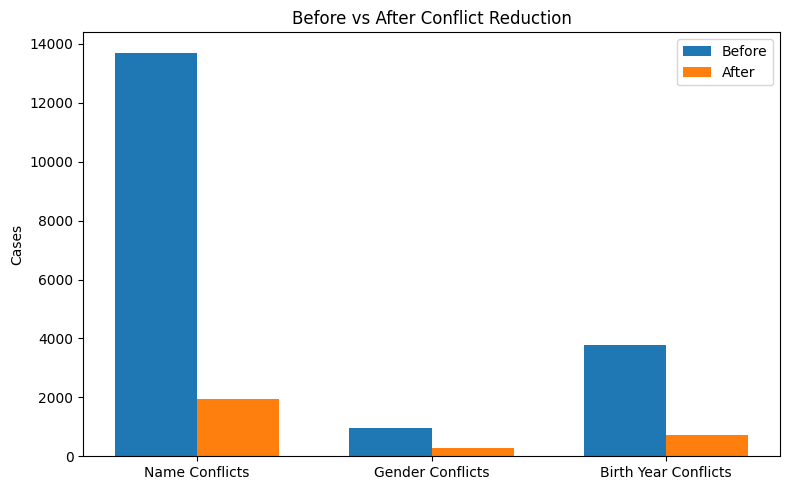

In [ ]:
from matplotlib import pyplot as plt
from math import pi
from PIL import Image
import pandas as pd

# Updated metrics
before_name = 13708
after_name = 1936

before_gender = 959
after_gender = 272

before_birth = 3793
after_birth = 711

before_clean = 34465
after_clean = 47651

before_warning = 11000
after_warning = 1385

before_critical = 4395
after_critical = 931

auto_resolved = 1617
manual_review = 1829

# Chart 1: Conflict Reduction
fig, ax = plt.subplots(figsize=(8,5))

categories = ['Name Conflicts', 'Gender Conflicts', 'Birth Year Conflicts']
before = [before_name, before_gender, before_birth]
after = [after_name, after_gender, after_birth]

x = range(len(categories))
width = 0.35

ax.bar([i - width/2 for i in x], before, width=width, label='Before')
ax.bar([i + width/2 for i in x], after, width=width, label='After')

ax.set_xticks(list(x))
ax.set_xticklabels(categories)
ax.set_ylabel('Cases')
ax.set_title('Before vs After Conflict Reduction')
ax.legend()

chart1 = "/mnt/data/conflict_reduction_updated.png"
plt.tight_layout()
plt.savefig(chart1)
plt.close()

# Chart 2: Data Quality Improvement
fig, ax = plt.subplots(figsize=(8,5))

categories2 = ['Clean', 'Warnings', 'Critical']
before2 = [before_clean, before_warning, before_critical]
after2 = [after_clean, after_warning, after_critical]

x2 = range(len(categories2))

ax.bar([i - width/2 for i in x2], before2, width=width, label='Before')
ax.bar([i + width/2 for i in x2], after2, width=width, label='After')

ax.set_xticks(list(x2))
ax.set_xticklabels(categories2)
ax.set_ylabel('Records')
ax.set_title('Data Quality Improvement')
ax.legend()

chart2 = "/mnt/data/data_quality_improvement_updated.png"
plt.tight_layout()
plt.savefig(chart2)
plt.close()

# Chart 3: Conflict Resolution Status
fig, ax = plt.subplots(figsize=(6,6))

labels = ['Auto Resolved', 'Manual Review']
sizes = [auto_resolved, manual_review]

ax.pie(sizes, labels=labels, autopct='%1.1f%%')
ax.set_title('Conflict Resolution Status')

chart3 = "/mnt/data/conflict_resolution_status_updated.png"
plt.tight_layout()
plt.savefig(chart3)
plt.close()

print("Charts generated successfully.")
print(chart1)
print(chart2)
print(chart3)
